In [17]:
from collections import defaultdict

from matplotlib import pyplot as plt
import strategies
from tqdm import tqdm
from game import Game

%matplotlib inline
%config InlineBackend.figure_format = 'svg'
plt.style.use('default')

In [18]:
def evaluate_strategy(strategy, num_trials=1000):
    results = []

    for _ in tqdm(range(num_trials)):
        game = Game()
        while not game.dead:
            game.play_strategy(strategy)
        results.append(game.move_count)

    return results

100%|██████████| 250/250 [00:00<00:00, 909.67it/s]


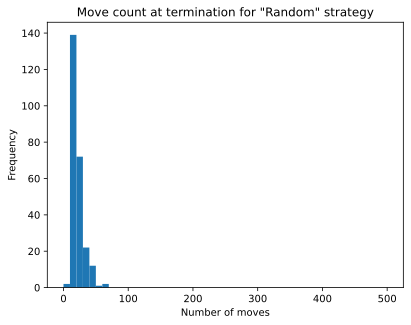

100%|██████████| 250/250 [00:04<00:00, 56.09it/s]


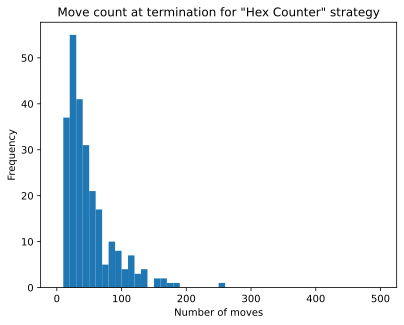

In [23]:
strategies_to_evaluate = [
    strategies.Random(),
    strategies.HexCounter(),
]

for strategy in strategies_to_evaluate:
    results = evaluate_strategy(strategy, num_trials=250)
    plt.title(f'Move count at termination for "{strategy.name}" strategy')
    plt.xlabel('Number of moves')
    plt.ylabel('Frequency')
    plt.hist(results, range=(0,500), bins=50)
    plt.show()